# CircLS pipeline, end to end: teleportation_n3

Teleportation on 3 qubits, exactly as it appears in the paper's Table 2 (`teleportation_n3`, the d = 3 and
d = 5 rows).  It is a non-Clifford program with a single T gate, lowered to a magic-state gadget.  Its S gate is
Clifford, so the front end emits no rotation for it and commutes it into the frame instead; commuting it
through the tail turns a terminal measurement into a Y-axis one, and the Y-free rewrite pays for that Y with
a second pi/4 rotation.  So the S is not free either, it is charged one step later: dropping it from the
input gives 3 PPMs and 25.3 blocks instead of 4 and 32.7.
For sampling, every |T> state is replaced by an |+> state (the paper's X-state proxy).  The proxy changes
nothing the compiler sees: the PPM sequence, the gadgets, and every mapping and routing decision are the ones
the real program gets; only the resource state differs, so the circuit stays Clifford and stim can sample it.

The notebook walks the pipeline in order: QASM -> NWQEC -> canonical form of the PPM program -> mapping,
routing and dynamic allocation -> TQEC block graph -> stim circuits -> logical error rate.  The compiler is
run in the paper's configuration: optimized mapping, first-use initialization, last-use freeing and
terminal-measurement re-selection.  The compiler's other optional passes (the lifetime-aware step scheduler
and parallel merge windows) are switched off.

The same program through the other toolchain of Table 2 is in
`gallery/baselines/teleportation_n3_topologiq/` (topologiq + tqec).

## 1. The logical circuit

In [1]:
import pathlib, sys, os, json, contextlib, io
HERE = pathlib.Path.cwd()
ROOT = pathlib.Path(os.environ.get("CIRCLS_ROOT", HERE.parents[2]))
for p in (str(ROOT), str(ROOT / "experiments"), str(ROOT / "gallery" / "tools")):
    if p not in sys.path:
        sys.path.insert(0, p)
for sub in ("data", "figures", "stim", "blockgraph"):
    (HERE / sub).mkdir(exist_ok=True)

qasm = pathlib.Path("data/1_teleportation_n3.qasm").read_text()
GATES = [l for l in qasm.splitlines()
         if l and not l.startswith(("OPENQASM", "include", "qreg", "creg", "measure"))]
print(f"Teleportation on 3 qubits (QASMBench teleportation_n3, gate for gate), {len(GATES)} gates: "
      f"{sum(g.startswith(('t ', 'tdg ')) for g in GATES)} T and {sum(g.startswith(('s ', 'sdg ')) for g in GATES)} S, "
      f"the rest Clifford")
print(qasm)

Teleportation on 3 qubits (QASMBench teleportation_n3, gate for gate), 8 gates: 1 T and 1 S, the rest Clifford
OPENQASM 2.0;
include "qelib1.inc";
qreg q[3];
h q[0];
t q[0];
h q[0];
h q[2];
s q[0];
cx q[2],q[1];
cx q[0],q[1];
h q[0];
creg c[3];
measure q -> c;



## 2. NWQEC: QASM to a Pauli-based circuit

NWQEC turns the gate list into Pauli rotations plus terminal measurements.  Each T becomes a pi/8
rotation; with the proxy it is read as a pi/4 rotation (`t_as_s`), so the sequence below has only
`s` rotations and terminal `m` measurements.  This stage is not part of CircLS: any front end that
produces such a sequence can be plugged in here.

In [2]:
from circls.interop.nwqec.frontend import load_clifford_t_as_s
from nb_helpers import show_ops, save_ops
pbc = load_clifford_t_as_s(qasm)
save_ops(pbc, "data/2_teleportation_n3_nwqec_pbc.txt")
kinds = {}
for o in pbc.ops: kinds[o.kind] = kinds.get(o.kind, 0) + 1
print(f"{len(pbc.ops)} ops: {kinds}")
show_ops(pbc, limit=12, tail=4)

4 ops: {'s': 1, 'm': 3}


$(X \otimes \mathbb{1} \otimes \mathbb{1})_{\pi/4}$  
$-Y \otimes X \otimes \mathbb{1}$ measurement  
$Z \otimes Z \otimes X$ measurement  
$\mathbb{1} \otimes \mathbb{1} \otimes X$ measurement

## 3. Canonical form of the PPM program

Three fixed rewrites run on the sequence before any placement.  Terminal-measurement re-selection
replaces the set of terminal measurements by products of lower weight (a greedy weight-reduction sweep;
exact, the original outcomes are reconstructed from the executed ones).  Weight-1 operations are moved
last.  The Y-free rewrite turns every Y axis into X/Z at the cost of extra pi/4 rotations.  Gadget
expansion then turns every pi/4 rotation into an ancilla patch, one joint PPM and a readout; the PPM
sequence is born in that step.  The step scheduler is not applied (paper configuration).


In [3]:
from circls.compiler.measure_reduce import reduce_measurements
from circls.interop.ir.pauli_ir import PauliCircuit
from circls.pipeline import reorder_weight1_last, drop_free_prefix, y_free_sweep, expand_gadgets

s_head = [o for o in pbc.ops if o.kind != "m"]
m_only = PauliCircuit(pbc.num_qubits, [o for o in pbc.ops if o.kind == "m"])
reduced, _ = reduce_measurements(m_only)           # terminal-measurement re-selection (paper configuration)
save_ops(reduced, "data/3_teleportation_n3_reselected.txt")
ordered, _ = reorder_weight1_last(reduced)         # the terminal measurements, weight-1 ones last
merged = PauliCircuit(ordered.num_qubits, list(s_head) + list(ordered.ops))
yfree = drop_free_prefix(y_free_sweep(merged))
save_ops(yfree, "data/3_teleportation_n3_yfree.txt")
program = expand_gadgets(yfree)
w = lambda c: sum(o.weight for o in c.ops if o.kind == "m")
print(f"NWQEC output          {len(pbc.ops):3d} ops  ({len(s_head)} rotations + {len(m_only.ops)} terminal measurements, total weight {w(m_only)})")
print(f"after re-selection    {len(s_head) + len(reduced.ops):3d} ops  ({len(reduced.ops)} terminal measurements, total weight {w(reduced)})")
print(f"after Y-free rewrite  {len(yfree.ops):3d} ops")
print(f"PPM program           {len(program.ops):3d} ops, {len(program.gadgets)} gadgets")

NWQEC output            4 ops  (1 rotations + 3 terminal measurements, total weight 6)
after re-selection      4 ops  (3 terminal measurements, total weight 5)
after Y-free rewrite    5 ops
PPM program             9 ops, 2 gadgets


## 4. CircLS compilation: mapping, routing, dynamic allocation

`compile_qasm` runs sections 2 and 3 again internally and then does the compiler's own work: the
mapper places the patches (`assignment="optimized"`), the router draws one ancilla path per PPM
through the free tiles, one PPM per merge window, and dynamic allocation initializes each patch at its
first use and frees it at its last use.  `KW` is the paper's configuration: terminal-measurement re-selection on, the
step scheduler and parallel windows off.  The one-line patch below is the paper's X-state proxy: gadget ancillas are prepared
in |+> instead of |Y>.

In [4]:
import circls.pipeline as P
from ablation import compile_kwargs
from benchsuite import tclass_suite
from nb_helpers import ppm_step_lines
case = {c.name: c for c in tclass_suite()}["teleportation_n3"]
KW = compile_kwargs("full", case)
KW.update(measure_reduction=True, step_scheduling=False, parallel_steps=False)    # paper configuration
_orig = P.to_experiment_inputs
def _x_proxy(*a, **k):
    specs, steps, init, final, prog = _orig(*a, **k)
    return specs, steps, {nm: ("X" if v == "Y" else v) for nm, v in init.items()}, final, prog
P.to_experiment_inputs = _x_proxy

def compile_d(d):
    with contextlib.redirect_stdout(io.StringIO()):
        return P.compile_qasm(qasm, distance=d, t_as_s=True, **KW)

cp3 = compile_d(3)
steps = cp3.experiment.ppm_sequence
pathlib.Path("data/4_teleportation_n3_ppm_sequence.txt").write_text("\n".join(ppm_step_lines(steps)) + "\n")
print(f"{len(steps)} executed PPMs; y0 is the |+> ancilla standing in for the T state, y1 the ancilla of "
      f"the pi/4 rotation the Y-free rewrite adds for the Y the commuted S leaves in a terminal measurement")
print("\n".join(ppm_step_lines(steps)))

4 executed PPMs; y0 is the |+> ancilla standing in for the T state, y1 the ancilla of the pi/4 rotation the Y-free rewrite adds for the Y the commuted S leaves in a terminal measurement
PPM 0: q0.X  y0.Z
PPM 1: q0.Z  y1.Z
PPM 2: q0.X  q1.X
PPM 3: q0.Z  q1.Z


## 5. Placement, routed ancilla paths, and the 3D spacetime structure

5 patches placed, 4 PPM steps (4 joint) routed; full detail in 5_teleportation_n3_placement_routing.json


3D structure: 5_teleportation_n3_spacetime.png (32.7 blocks: the paper's Table 2 cell for teleportation_n3, d = 3)


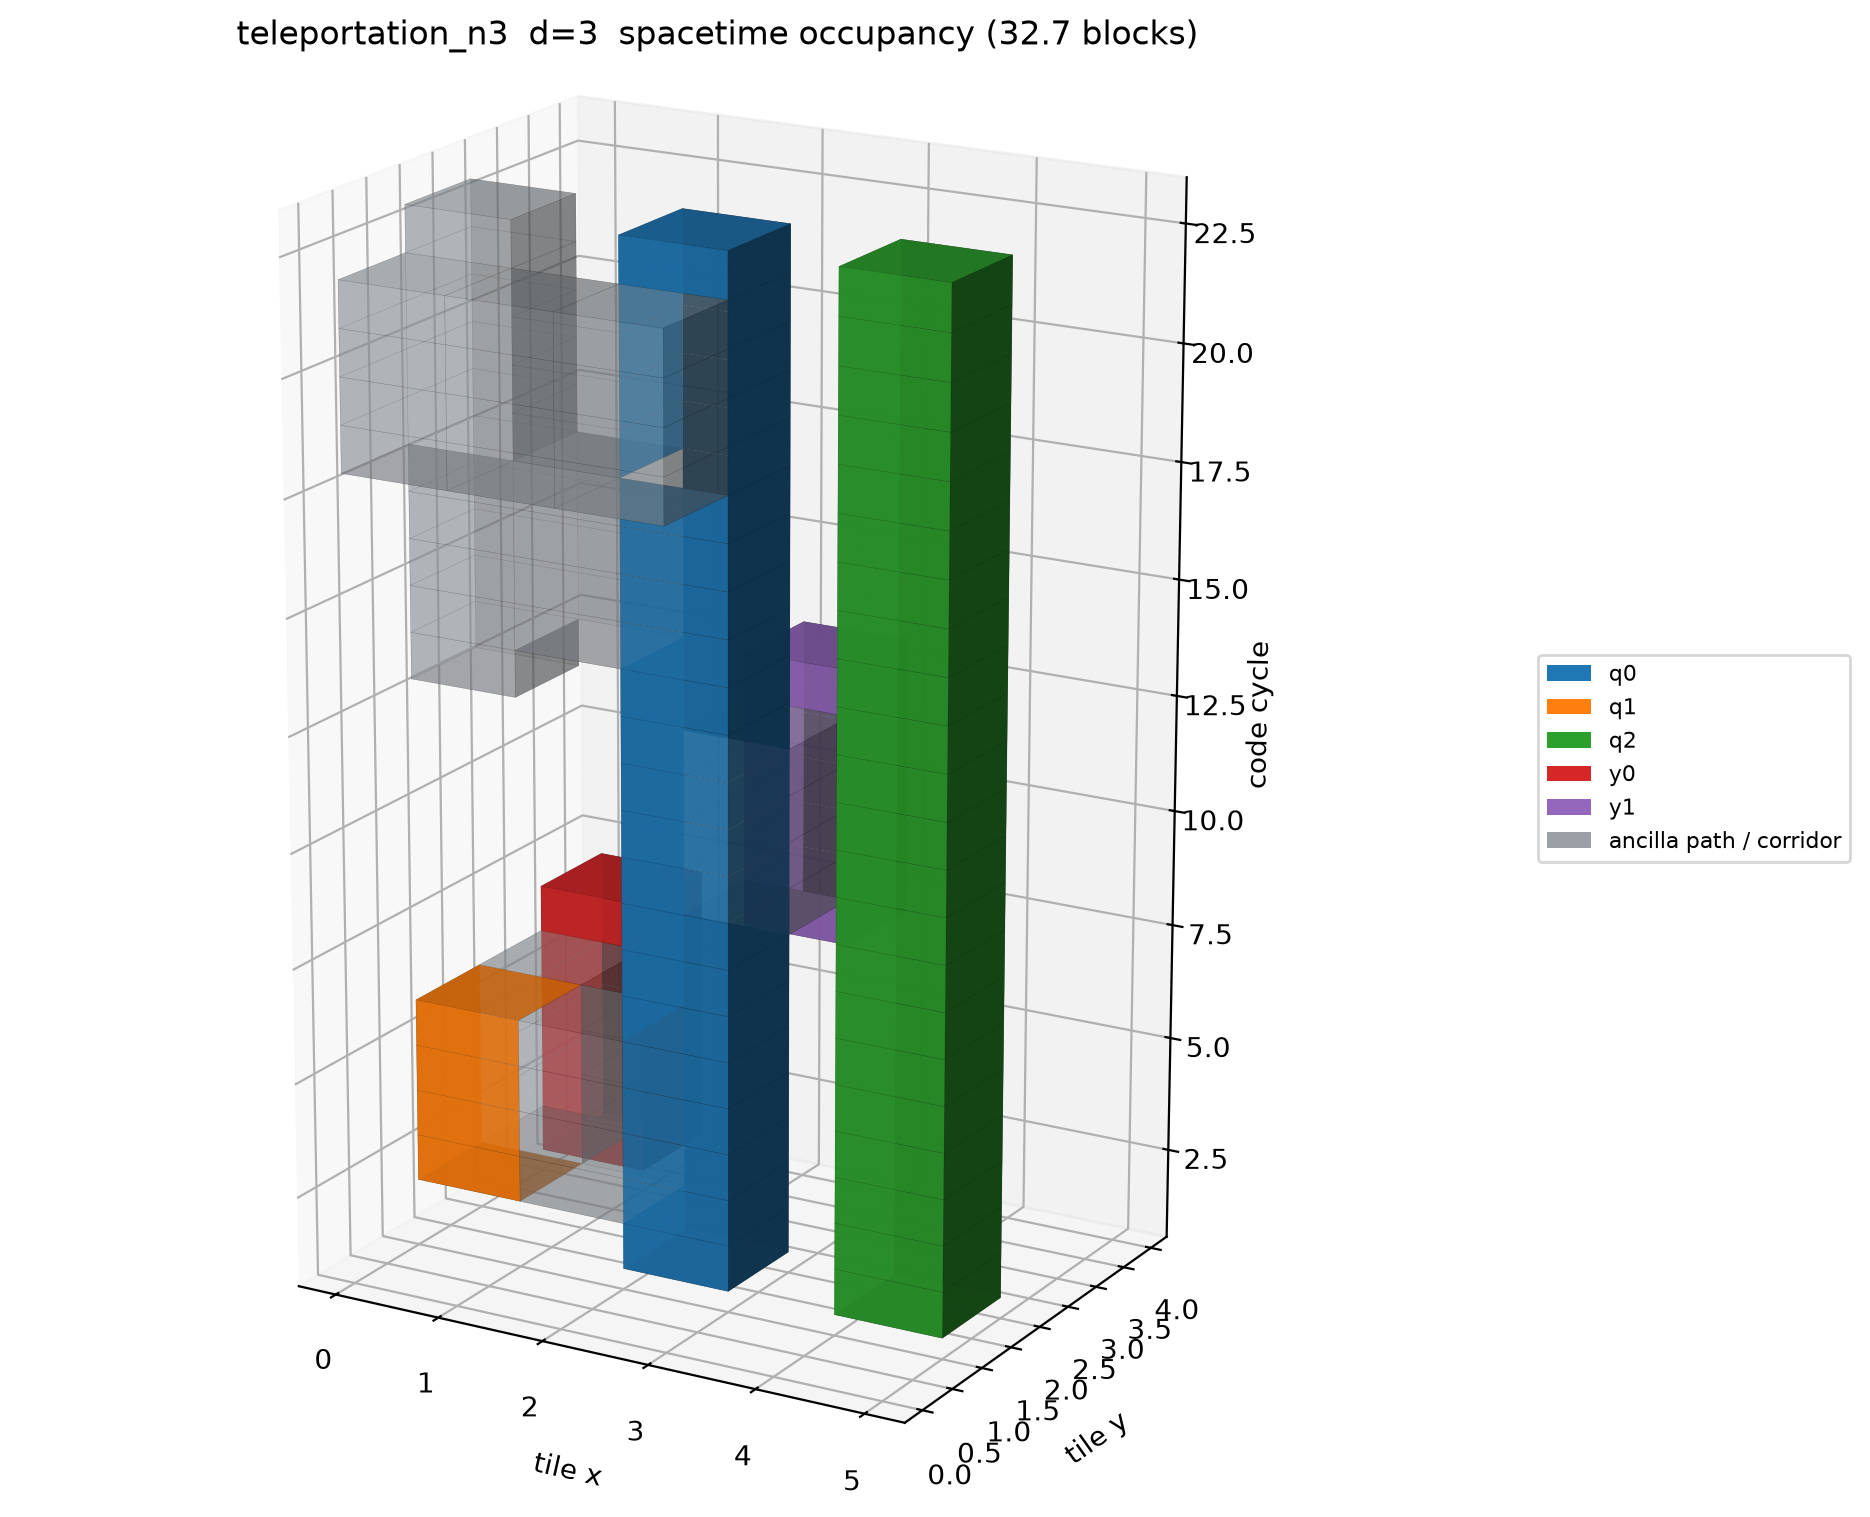

In [5]:
from circls.metrics.experiment_stats import experiment_stats
from render_spacetime import render
from nb_helpers import save_routing
import shutil
print(save_routing(cp3, steps, "data/5_teleportation_n3_placement_routing.json"))
stats = experiment_stats(cp3.experiment, cp3.circuit)
png, js, _ = render(stats, cp3.placement, "teleportation_n3", str(HERE / "figures"), distance=3)
shutil.move(str(HERE / "figures" / "teleportation_n3_schedule.json"), str(HERE / "data" / "5_teleportation_n3_schedule.json"))
png2 = str(HERE / "figures" / "5_teleportation_n3_spacetime.png"); shutil.move(png, png2); png = png2
print("3D structure:", pathlib.Path(png).name, f"({stats.volume_blocks:.1f} blocks: the paper's Table 2 cell for teleportation_n3, d = 3)")
from IPython.display import Image, display
display(Image(png, width=640))

## 6. TQEC block-graph export (rotatable)

The schedule is translated into tqec's block graph: one cube layer per scheduling batch plus an
initialization and a readout layer, a patch's
live range as a column of cubes, each merge as corridor cubes piped to the patches it joins.  Where a
patch touches more than one corridor tile the seam can sit on either side; the exporter searches those
choices and keeps the first embedding that satisfies tqec's wall rules.  The result is validated with
tqec's own toolchain (`blockgraph/tqec_validation.txt`).

-> blockgraph/teleportation_n3_blockgraph.html: 30 cubes, 29 pipes -- drag to rotate (the .dae loads into tqec / SketchUp)


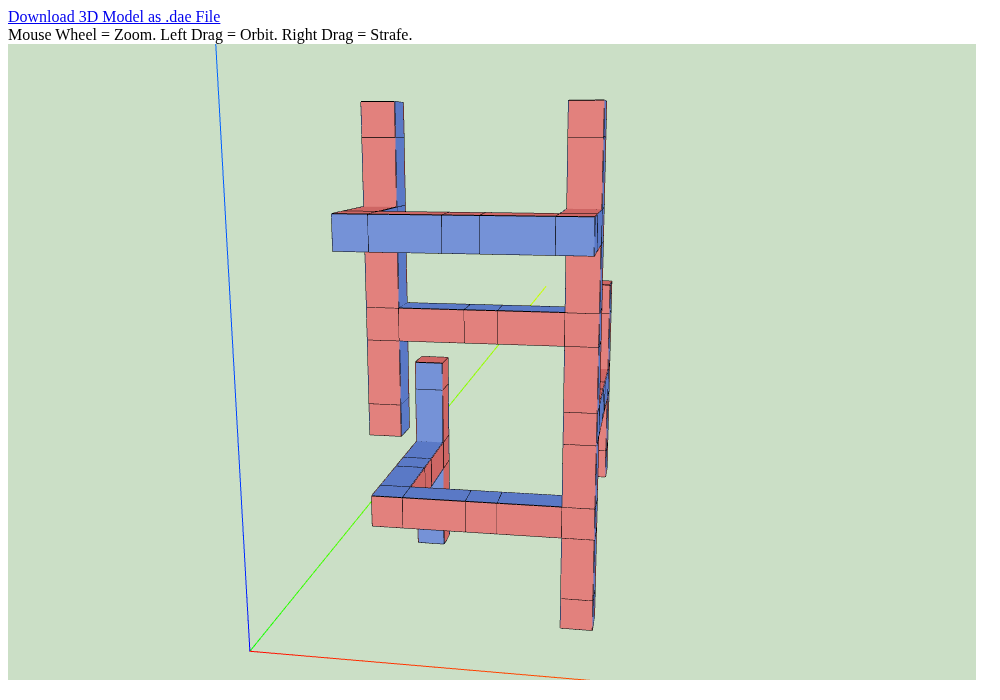

In [6]:
from export_blockgraph_auto import auto_export
BG = HERE / "blockgraph"
if not list(BG.glob("*_blockgraph.dae")):
    auto_export(cp3, "teleportation_n3", BG, tqec_python=os.environ.get("TQEC_PYTHON"))
hits = sorted(BG.glob("*_blockgraph.html"))
from IPython.display import IFrame, Image, display
if hits:
    bs = json.loads((BG / "teleportation_n3_blockstructure.json").read_text())
    print(f"-> blockgraph/{hits[0].name}: {len(bs['cubes'])} cubes, {len(bs['pipes'])} pipes -- drag to rotate "
          f"(the .dae loads into tqec / SketchUp)")
    snap = HERE / "figures" / "6_teleportation_n3_blockgraph.png"
    if snap.exists():
        display(Image(str(snap), width=640))
    display(IFrame("blockgraph/" + hits[0].name, width=760, height=480))
else:
    print((BG / "export_log.txt").read_text())

## 7. stim circuits: clean and noisy, d = 3, 5, 7

In [7]:
from noise_inject import inject_uniform_noise
from circls.metrics.circuit_stats import circuit_stats
P_NOISY = 1e-3
circuits = {}
for d in (3, 5, 7):
    cp = cp3 if d == 3 else compile_d(d)
    clean = cp.circuit
    circuits[d] = clean
    (HERE / "stim" / f"d{d}").mkdir(exist_ok=True)
    pathlib.Path(f"stim/d{d}/7_teleportation_n3_clean.stim").write_text(str(clean))
    pathlib.Path(f"stim/d{d}/7_teleportation_n3_noisy_p1e-3.stim").write_text(str(inject_uniform_noise(clean, P_NOISY)))
    st = experiment_stats(cp.experiment, clean); cs = circuit_stats(clean)
    print(f"d={d}: {clean.num_qubits} qubits, {clean.num_detectors} detectors, {clean.num_observables} observables, "
          f"{st.volume_blocks:.1f} blocks, {cs.qubit_rounds} qubit-cycles "
          f"({'the paper\'s Table 2 row' if d < 7 else 'no Table 2 row at this distance'})")

d=3: 256 qubits, 657 detectors, 1 observables, 32.7 blocks, 1712 qubit-cycles (the paper's Table 2 row)


d=5: 649 qubits, 2927 detectors, 1 observables, 27.6 blocks, 6770 qubit-cycles (the paper's Table 2 row)


d=7: 1218 qubits, 7773 detectors, 1 observables, 25.4 blocks, 17196 qubit-cycles (no Table 2 row at this distance)


## 8. Measured logical error rate of the CircLS-compiled circuits

PyMatching, d = 3, 5, 7 at p = 5e-4 .. 2e-2, circuit-level depolarizing noise.  The d = 3 and d = 5
points at p = 5e-4 are the paper's Table 2 LER cells for this program.

d=3 p=0.0005: LER=0.01888  (944 errors / 50000 shots)
d=3 p=0.001: LER=0.06354  (3177 errors / 50000 shots)
d=3 p=0.002: LER=0.2021  (10105 errors / 50000 shots)
d=3 p=0.01: LER=0.5005  (25026 errors / 50000 shots)
d=3 p=0.02: LER=0.4978  (24892 errors / 50000 shots)
d=5 p=0.0005: LER=0.00248  (124 errors / 50000 shots)
d=5 p=0.001: LER=0.01822  (911 errors / 50000 shots)
d=5 p=0.002: LER=0.1242  (6210 errors / 50000 shots)
d=5 p=0.01: LER=0.4974  (24868 errors / 50000 shots)
d=5 p=0.02: LER=0.5011  (25057 errors / 50000 shots)
d=7 p=0.0005: LER=0.0003314  (116 errors / 350000 shots)
d=7 p=0.001: LER=0.00566  (283 errors / 50000 shots)
d=7 p=0.002: LER=0.06754  (3377 errors / 50000 shots)
d=7 p=0.01: LER=0.4994  (24969 errors / 50000 shots)
d=7 p=0.02: LER=0.5017  (25087 errors / 50000 shots)


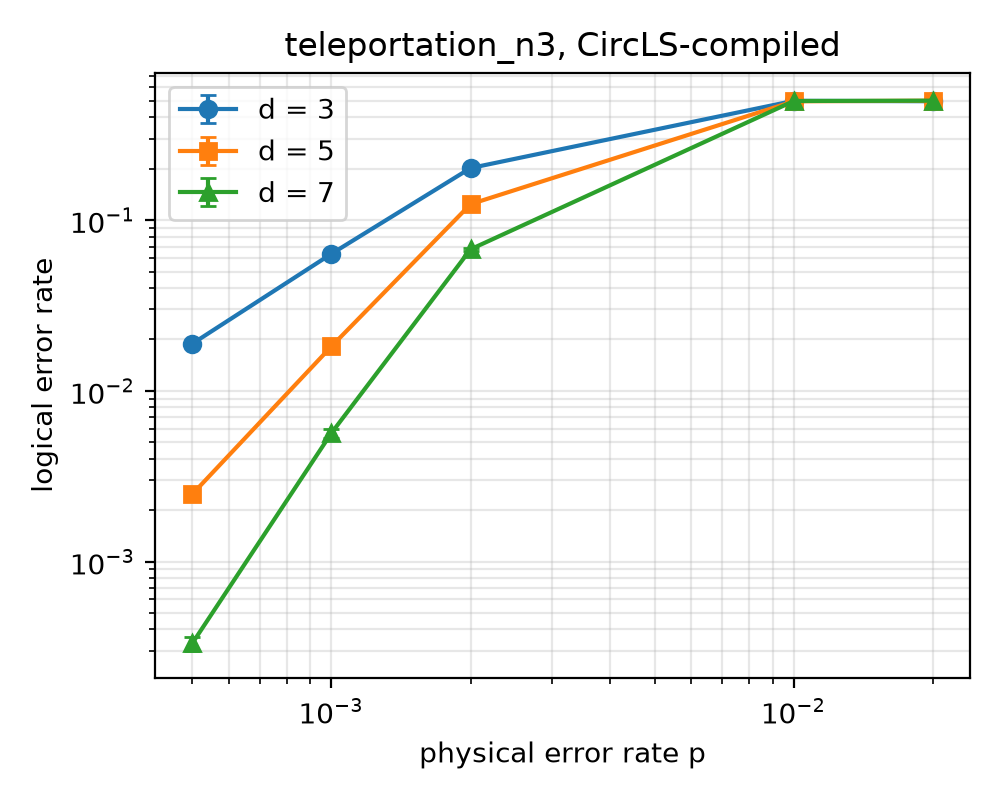

In [8]:
from ler_sampler import measure_ler
from nb_helpers import save_ler_points, plot_ler
PS = [5e-4, 1e-3, 2e-3, 1e-2, 2e-2]
WORKERS = 32     # parallel sampling processes -- set to your machine
pts_file = pathlib.Path("data/8_teleportation_n3_ler_points.json")
if pts_file.exists():           # precomputed by this notebook's last full run; delete the file to resample
    raw = json.loads(pts_file.read_text())      # keys look like "d3_p0.0005"
    points = {(int(k.split("_p")[0][1:]), float(k.split("_p")[1])): (v["ler"], v["errors"], v["shots"])
              for k, v in raw.items()}
else:
    points = {(d, p): measure_ler(inject_uniform_noise(clean, p), workers=WORKERS)
              for d, clean in circuits.items() for p in PS}
    save_ler_points(points, str(pts_file))
plot_ler(points, PS, "teleportation_n3, CircLS-compiled", "figures/8_teleportation_n3_ler.png")
for (d, p), (ler, e, s) in sorted(points.items()):
    print(f"d={d} p={p:g}: LER={ler:.4g}  ({e} errors / {s} shots)")
from IPython.display import Image, display
display(Image("figures/8_teleportation_n3_ler.png", width=560))